In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils .data import DataLoader
from torchvision import datasets, transforms
from torchvision import models

from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    top_k_accuracy_score,
    balanced_accuracy_score
)



device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Device: cuda


In [2]:
def testing(TEST_DIR,MODEL_PATH,model):
    checkpoint = torch.load(
        MODEL_PATH,
        map_location=device,
        weights_only=False
    )

    classes = checkpoint["classes"]
    num_classes = checkpoint["num_classes"]

    print("Number of classes:", num_classes)
    print("Classes:", classes)

    test_transform = transforms.Compose([
        transforms.Resize(
            352,
            interpolation=transforms.InterpolationMode.BILINEAR,
            antialias=True
        ),
        transforms.CenterCrop(320),
        transforms.ToTensor(),
        transforms.Normalize(
            [0.485, 0.456, 0.406],
            [0.229, 0.224, 0.225]
        )
    ])

    test_dataset = datasets.ImageFolder(
        TEST_DIR,
        transform=test_transform
    )

    assert test_dataset.classes == classes, (
        "different testing set"
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=32,
        shuffle=False,
        num_workers=0,
        pin_memory=torch.cuda.is_available()
    )

    print("Test images:", len(test_dataset))

    

    model.fc = nn.Linear(
        model.fc.in_features,
        num_classes
    )

    model.load_state_dict(checkpoint["model_state_dict"])
    model = model.to(device)
    model.eval()

    print("Model loaded successfully")

    correct = 0
    total = 0

    all_predictions = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            predictions = outputs.argmax(dim=1)

            correct += (predictions == labels).sum().item()
            total += labels.size(0)

            all_probs.append(probs.cpu())
            all_predictions.extend(predictions.cpu().tolist())
            all_labels.extend(labels.cpu().tolist())

    test_accuracy = correct / total

    print(f"Test accuracy: {test_accuracy:.4f}")
    print(f"Correct predictions: {correct}/{total}")

    y_true = np.array(all_labels)
    y_pred = np.array(all_predictions)
    all_probs = torch.cat(all_probs).numpy()

    top5_accuracy = top_k_accuracy_score(
        y_true, all_probs, k=5, labels=list(range(num_classes))
    )

    macro_precision = precision_score(
        y_true, y_pred,
        average="macro",
        zero_division=0
    )

    macro_recall = recall_score(
        y_true, y_pred,
        average="macro",
        zero_division=0
    )

    macro_f1 = f1_score(
        y_true, y_pred,
        average="macro",
        zero_division=0
    )

    weighted_f1 = f1_score(
        y_true, y_pred,
        average="weighted",
        zero_division=0
    )

    balance_accuracy = balanced_accuracy_score(y_true, y_pred)

    print(f"Top-1 Accuracy:    {test_accuracy:.4f}")
    print(f"Top5 Accuracy:    {top5_accuracy:.4f}")
    print(f"Macro Precision:  {macro_precision:.4f}")
    print(f"Macro Recall:     {macro_recall:.4f}")
    print(f"Macro F1:         {macro_f1:.4f}")
    print(f"Weighted F1:      {weighted_f1:.4f}")
    print(f"Balanced Accuracy:      {balance_accuracy:.4f}")

    class_names = test_dataset.classes
    num_classes = len(class_names)

    cm_normalized = confusion_matrix(
        y_true,
        y_pred,
        labels=range(num_classes),
        normalize="true"
    )

    # fig, ax = plt.subplots(figsize=(14, 12))

    # sns.heatmap(
    #     cm_normalized,
    #     cmap="Blues",
    #     vmin=0,
    #     vmax=1,
    #     xticklabels=False,
    #     yticklabels=False,
    #     ax=ax
    # )

    # ax.set_title("Normalised Confusion Matrix: ResNet50")
    # ax.set_xlabel("Predicted Class")
    # ax.set_ylabel("True Class")

    # fig.tight_layout()
    # plt.show()

In [3]:
DATA_ROOT = Path(r"D:/dataset/sampled_500")

TEST_DIR = DATA_ROOT / "val"
MODEL_PATH = "inat_resnet18_500_ptclasses_imagenet.pth"

model = models.resnet18(weights=None)

testing(TEST_DIR,MODEL_PATH,model)

Number of classes: 500
Classes: ['00001_Animalia_Annelida_Polychaeta_Sabellida_Sabellidae_Sabella_spallanzanii', '00003_Animalia_Annelida_Polychaeta_Sabellida_Serpulidae_Spirobranchus_cariniferus', '00018_Animalia_Arthropoda_Arachnida_Araneae_Araneidae_Argiope_bruennichi', '00024_Animalia_Arthropoda_Arachnida_Araneae_Araneidae_Cyclosa_turbinata', '00038_Animalia_Arthropoda_Arachnida_Araneae_Araneidae_Neoscona_crucifera', '00055_Animalia_Arthropoda_Arachnida_Araneae_Filistatidae_Kukulcania_hibernalis', '00128_Animalia_Arthropoda_Arachnida_Araneae_Thomisidae_Synema_globosum', '00145_Animalia_Arthropoda_Arachnida_Opiliones_Phalangiidae_Phalangium_opilio', '00159_Animalia_Arthropoda_Chilopoda_Scolopendromorpha_Scolopendridae_Scolopendra_heros', '00203_Animalia_Arthropoda_Insecta_Coleoptera_Carabidae_Cicindela_hirticollis', '00216_Animalia_Arthropoda_Insecta_Coleoptera_Carabidae_Scaphinotus_angusticollis', '00230_Animalia_Arthropoda_Insecta_Coleoptera_Cerambycidae_Knulliana_cincta', '00234_

Number of classes: 500
Classes: ['00001_Animalia_Annelida_Polychaeta_Sabellida_Sabellidae_Sabella_spallanzanii', '00003_Animalia_Annelida_Polychaeta_Sabellida_Serpulidae_Spirobranchus_cariniferus', '00018_Animalia_Arthropoda_Arachnida_Araneae_Araneidae_Argiope_bruennichi', '00024_Animalia_Arthropoda_Arachnida_Araneae_Araneidae_Cyclosa_turbinata', '00038_Animalia_Arthropoda_Arachnida_Araneae_Araneidae_Neoscona_crucifera', '00055_Animalia_Arthropoda_Arachnida_Araneae_Filistatidae_Kukulcania_hibernalis', '00128_Animalia_Arthropoda_Arachnida_Araneae_Thomisidae_Synema_globosum', '00145_Animalia_Arthropoda_Arachnida_Opiliones_Phalangiidae_Phalangium_opilio', '00159_Animalia_Arthropoda_Chilopoda_Scolopendromorpha_Scolopendridae_Scolopendra_heros', '00203_Animalia_Arthropoda_Insecta_Coleoptera_Carabidae_Cicindela_hirticollis', '00216_Animalia_Arthropoda_Insecta_Coleoptera_Carabidae_Scaphinotus_angusticollis', '00230_Animalia_Arthropoda_Insecta_Coleoptera_Cerambycidae_Knulliana_cincta', '00234_

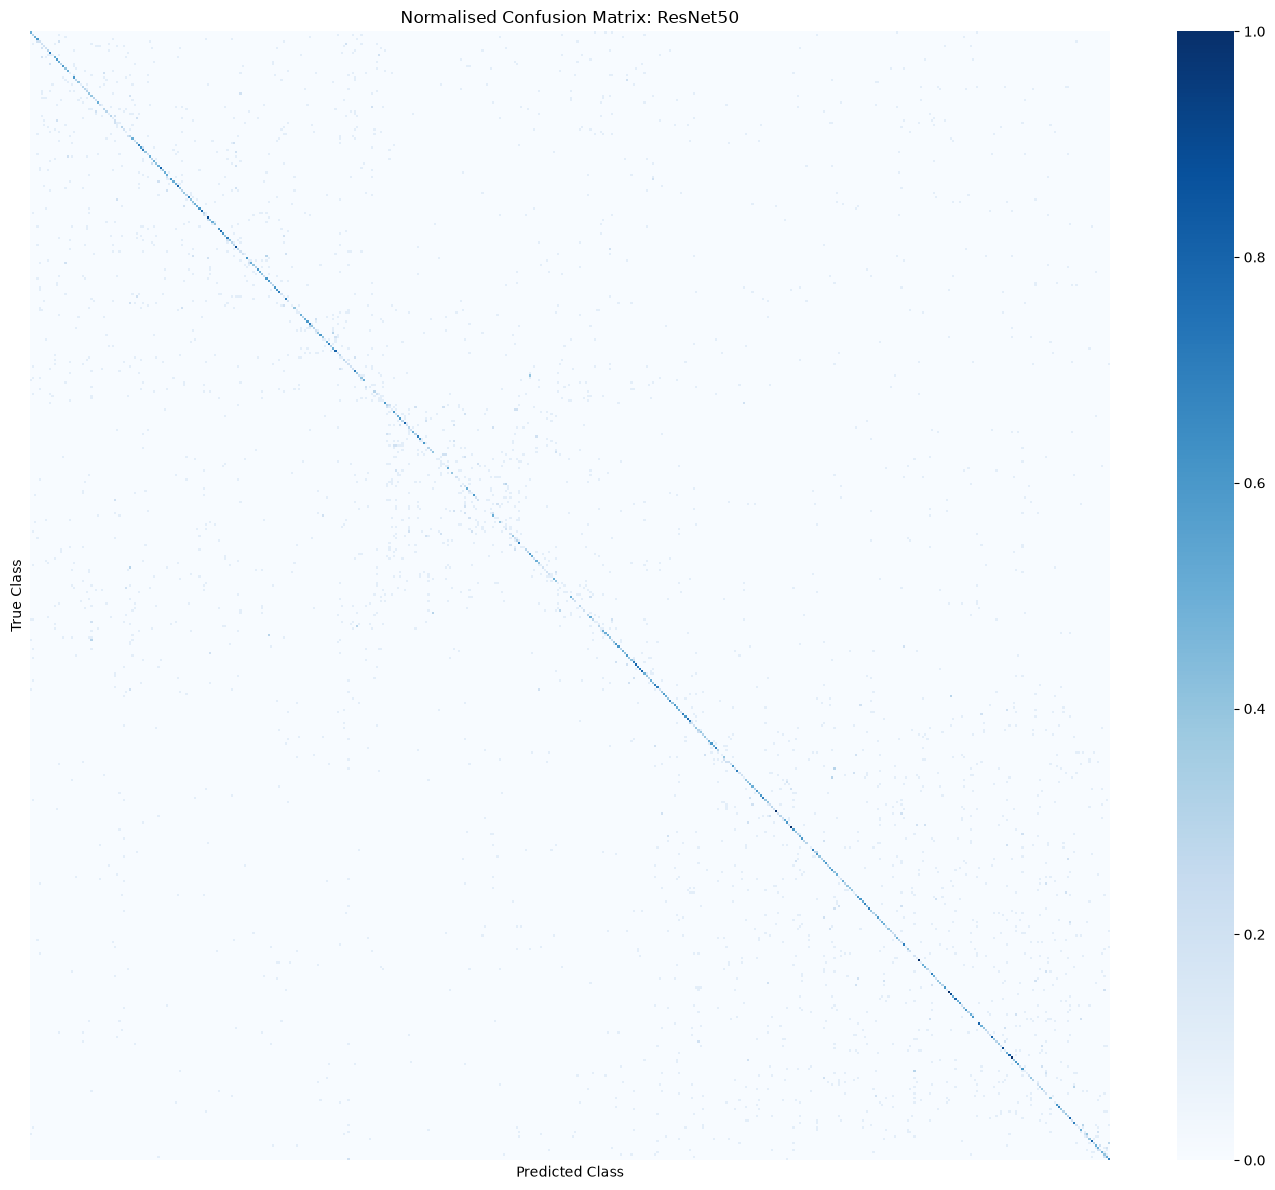

In [7]:
DATA_ROOT = Path(r"D:/dataset/sampled_500")

TEST_DIR = DATA_ROOT / "val"
MODEL_PATH = "inat_resnet18_500_npclasses_imagenet.pth"

model = models.resnet18(weights=None)

testing(TEST_DIR,MODEL_PATH,model)

Number of classes: 500
Classes: ['00001_Animalia_Annelida_Polychaeta_Sabellida_Sabellidae_Sabella_spallanzanii', '00003_Animalia_Annelida_Polychaeta_Sabellida_Serpulidae_Spirobranchus_cariniferus', '00018_Animalia_Arthropoda_Arachnida_Araneae_Araneidae_Argiope_bruennichi', '00024_Animalia_Arthropoda_Arachnida_Araneae_Araneidae_Cyclosa_turbinata', '00038_Animalia_Arthropoda_Arachnida_Araneae_Araneidae_Neoscona_crucifera', '00055_Animalia_Arthropoda_Arachnida_Araneae_Filistatidae_Kukulcania_hibernalis', '00128_Animalia_Arthropoda_Arachnida_Araneae_Thomisidae_Synema_globosum', '00145_Animalia_Arthropoda_Arachnida_Opiliones_Phalangiidae_Phalangium_opilio', '00159_Animalia_Arthropoda_Chilopoda_Scolopendromorpha_Scolopendridae_Scolopendra_heros', '00203_Animalia_Arthropoda_Insecta_Coleoptera_Carabidae_Cicindela_hirticollis', '00216_Animalia_Arthropoda_Insecta_Coleoptera_Carabidae_Scaphinotus_angusticollis', '00230_Animalia_Arthropoda_Insecta_Coleoptera_Cerambycidae_Knulliana_cincta', '00234_

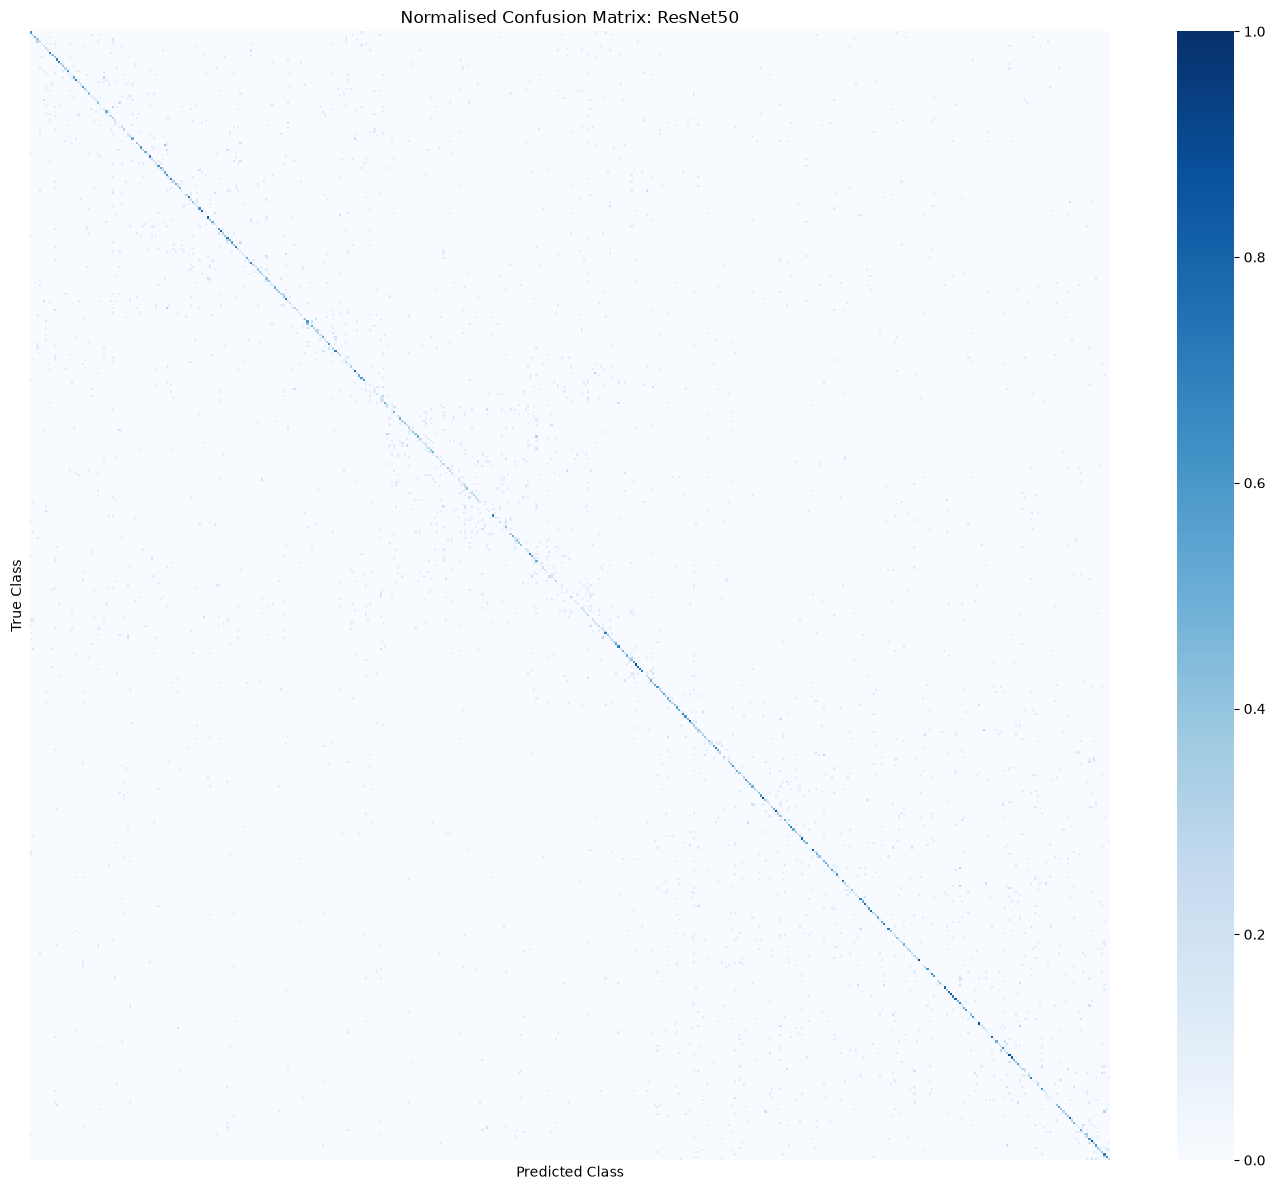

In [11]:
DATA_ROOT = Path(r"D:/dataset/sampled_500")

TEST_DIR = DATA_ROOT / "val"
MODEL_PATH = "inat_resnet50_500_npclasses_imagenet.pth"

model = models.resnet50(weights=None)

testing(TEST_DIR,MODEL_PATH,model)

Number of classes: 500
Classes: ['00001_Animalia_Annelida_Polychaeta_Sabellida_Sabellidae_Sabella_spallanzanii', '00003_Animalia_Annelida_Polychaeta_Sabellida_Serpulidae_Spirobranchus_cariniferus', '00018_Animalia_Arthropoda_Arachnida_Araneae_Araneidae_Argiope_bruennichi', '00024_Animalia_Arthropoda_Arachnida_Araneae_Araneidae_Cyclosa_turbinata', '00038_Animalia_Arthropoda_Arachnida_Araneae_Araneidae_Neoscona_crucifera', '00055_Animalia_Arthropoda_Arachnida_Araneae_Filistatidae_Kukulcania_hibernalis', '00128_Animalia_Arthropoda_Arachnida_Araneae_Thomisidae_Synema_globosum', '00145_Animalia_Arthropoda_Arachnida_Opiliones_Phalangiidae_Phalangium_opilio', '00159_Animalia_Arthropoda_Chilopoda_Scolopendromorpha_Scolopendridae_Scolopendra_heros', '00203_Animalia_Arthropoda_Insecta_Coleoptera_Carabidae_Cicindela_hirticollis', '00216_Animalia_Arthropoda_Insecta_Coleoptera_Carabidae_Scaphinotus_angusticollis', '00230_Animalia_Arthropoda_Insecta_Coleoptera_Cerambycidae_Knulliana_cincta', '00234_

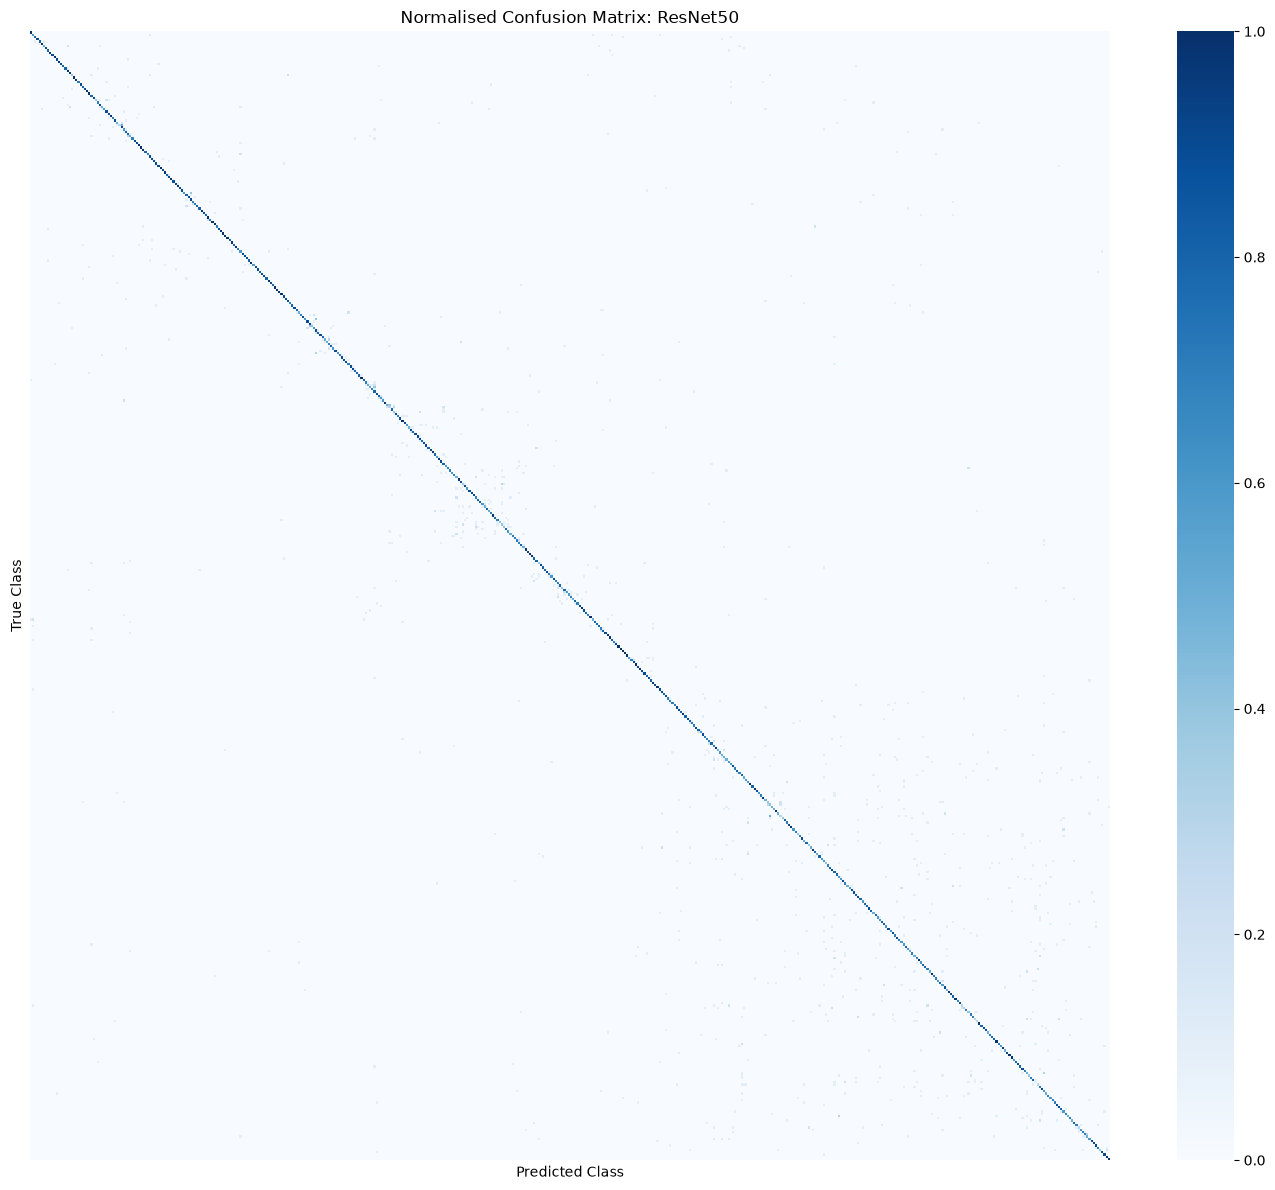

In [14]:
DATA_ROOT = Path(r"D:/dataset/sampled_500")

TEST_DIR = DATA_ROOT / "val"
MODEL_PATH = "inat_resnet50_500_ptclasses_imagenet.pth"

model = models.resnet50(weights=None)

testing(TEST_DIR,MODEL_PATH,model)

Number of classes: 1000
Classes: ['00001_Animalia_Annelida_Polychaeta_Sabellida_Sabellidae_Sabella_spallanzanii', '00003_Animalia_Annelida_Polychaeta_Sabellida_Serpulidae_Spirobranchus_cariniferus', '00004_Animalia_Arthropoda_Arachnida_Araneae_Agelenidae_Eratigena_duellica', '00018_Animalia_Arthropoda_Arachnida_Araneae_Araneidae_Argiope_bruennichi', '00024_Animalia_Arthropoda_Arachnida_Araneae_Araneidae_Cyclosa_turbinata', '00030_Animalia_Arthropoda_Arachnida_Araneae_Araneidae_Larinioides_cornutus', '00038_Animalia_Arthropoda_Arachnida_Araneae_Araneidae_Neoscona_crucifera', '00052_Animalia_Arthropoda_Arachnida_Araneae_Corinnidae_Nyssus_coloripes', '00055_Animalia_Arthropoda_Arachnida_Araneae_Filistatidae_Kukulcania_hibernalis', '00061_Animalia_Arthropoda_Arachnida_Araneae_Oxyopidae_Oxyopes_salticus', '00063_Animalia_Arthropoda_Arachnida_Araneae_Oxyopidae_Peucetia_viridans', '00105_Animalia_Arthropoda_Arachnida_Araneae_Sparassidae_Olios_giganteus', '00116_Animalia_Arthropoda_Arachnida_A

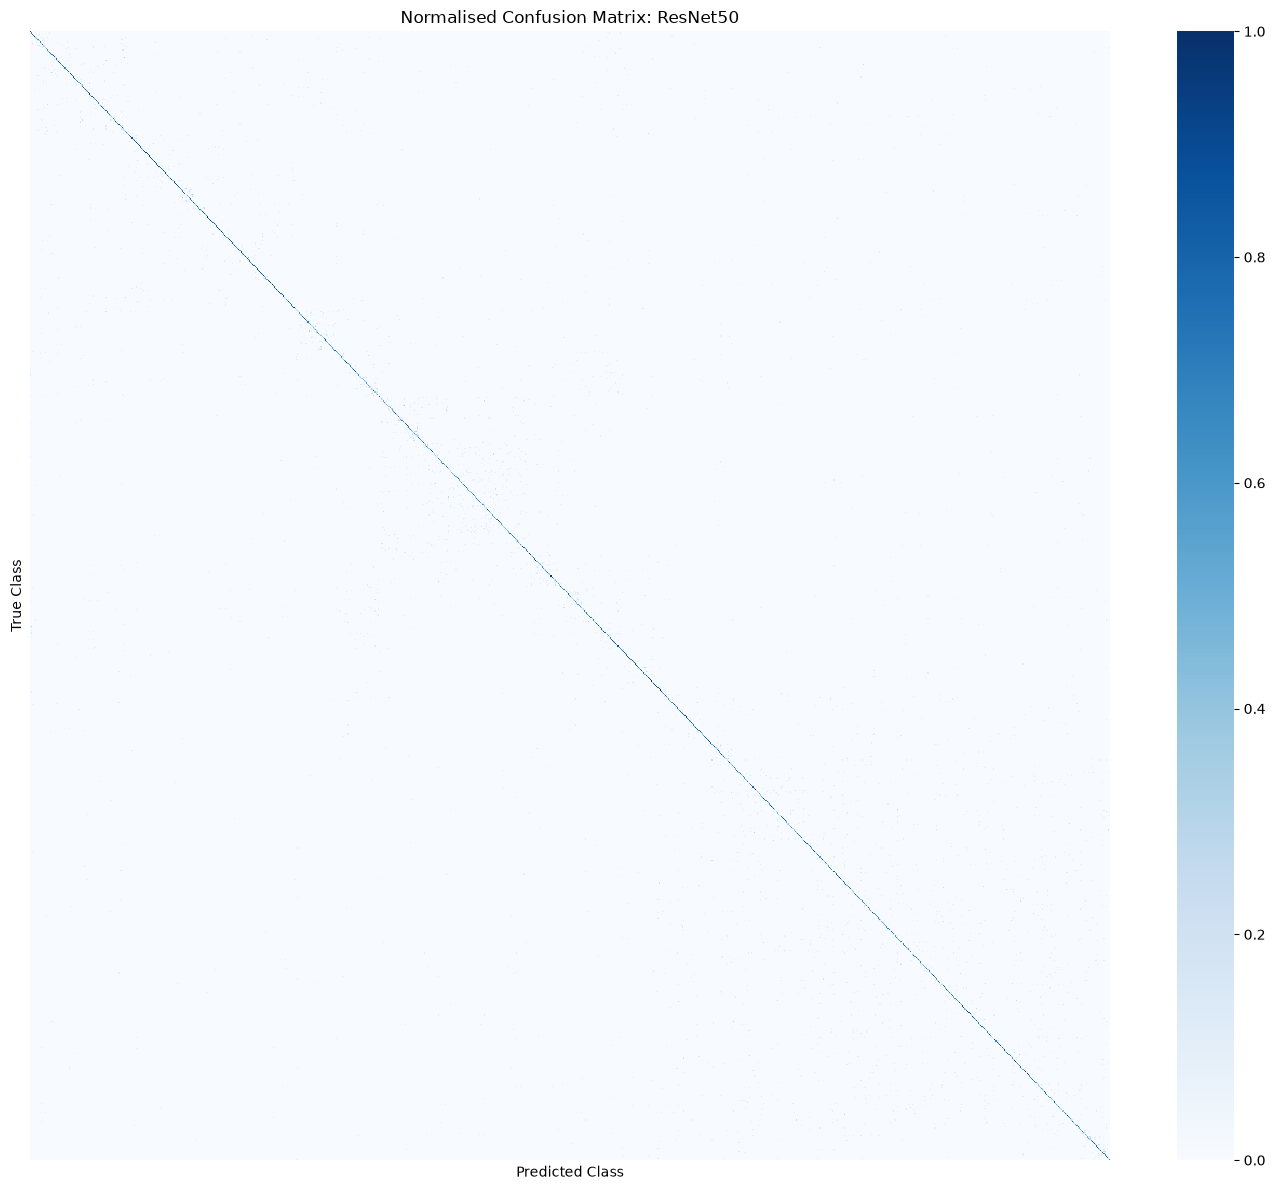

In [ ]:
DATA_ROOT = Path(r"D:/dataset/sampled_1000")

TEST_DIR = DATA_ROOT / "val"
MODEL_PATH = "inat_resnet18_1000_ptclasses_imagenet.pth"

model = models.resnet18(weights=None)

testing(TEST_DIR,MODEL_PATH,model)
#1m29.5s

Number of classes: 1000
Classes: ['00001_Animalia_Annelida_Polychaeta_Sabellida_Sabellidae_Sabella_spallanzanii', '00003_Animalia_Annelida_Polychaeta_Sabellida_Serpulidae_Spirobranchus_cariniferus', '00004_Animalia_Arthropoda_Arachnida_Araneae_Agelenidae_Eratigena_duellica', '00018_Animalia_Arthropoda_Arachnida_Araneae_Araneidae_Argiope_bruennichi', '00024_Animalia_Arthropoda_Arachnida_Araneae_Araneidae_Cyclosa_turbinata', '00030_Animalia_Arthropoda_Arachnida_Araneae_Araneidae_Larinioides_cornutus', '00038_Animalia_Arthropoda_Arachnida_Araneae_Araneidae_Neoscona_crucifera', '00052_Animalia_Arthropoda_Arachnida_Araneae_Corinnidae_Nyssus_coloripes', '00055_Animalia_Arthropoda_Arachnida_Araneae_Filistatidae_Kukulcania_hibernalis', '00061_Animalia_Arthropoda_Arachnida_Araneae_Oxyopidae_Oxyopes_salticus', '00063_Animalia_Arthropoda_Arachnida_Araneae_Oxyopidae_Peucetia_viridans', '00105_Animalia_Arthropoda_Arachnida_Araneae_Sparassidae_Olios_giganteus', '00116_Animalia_Arthropoda_Arachnida_A

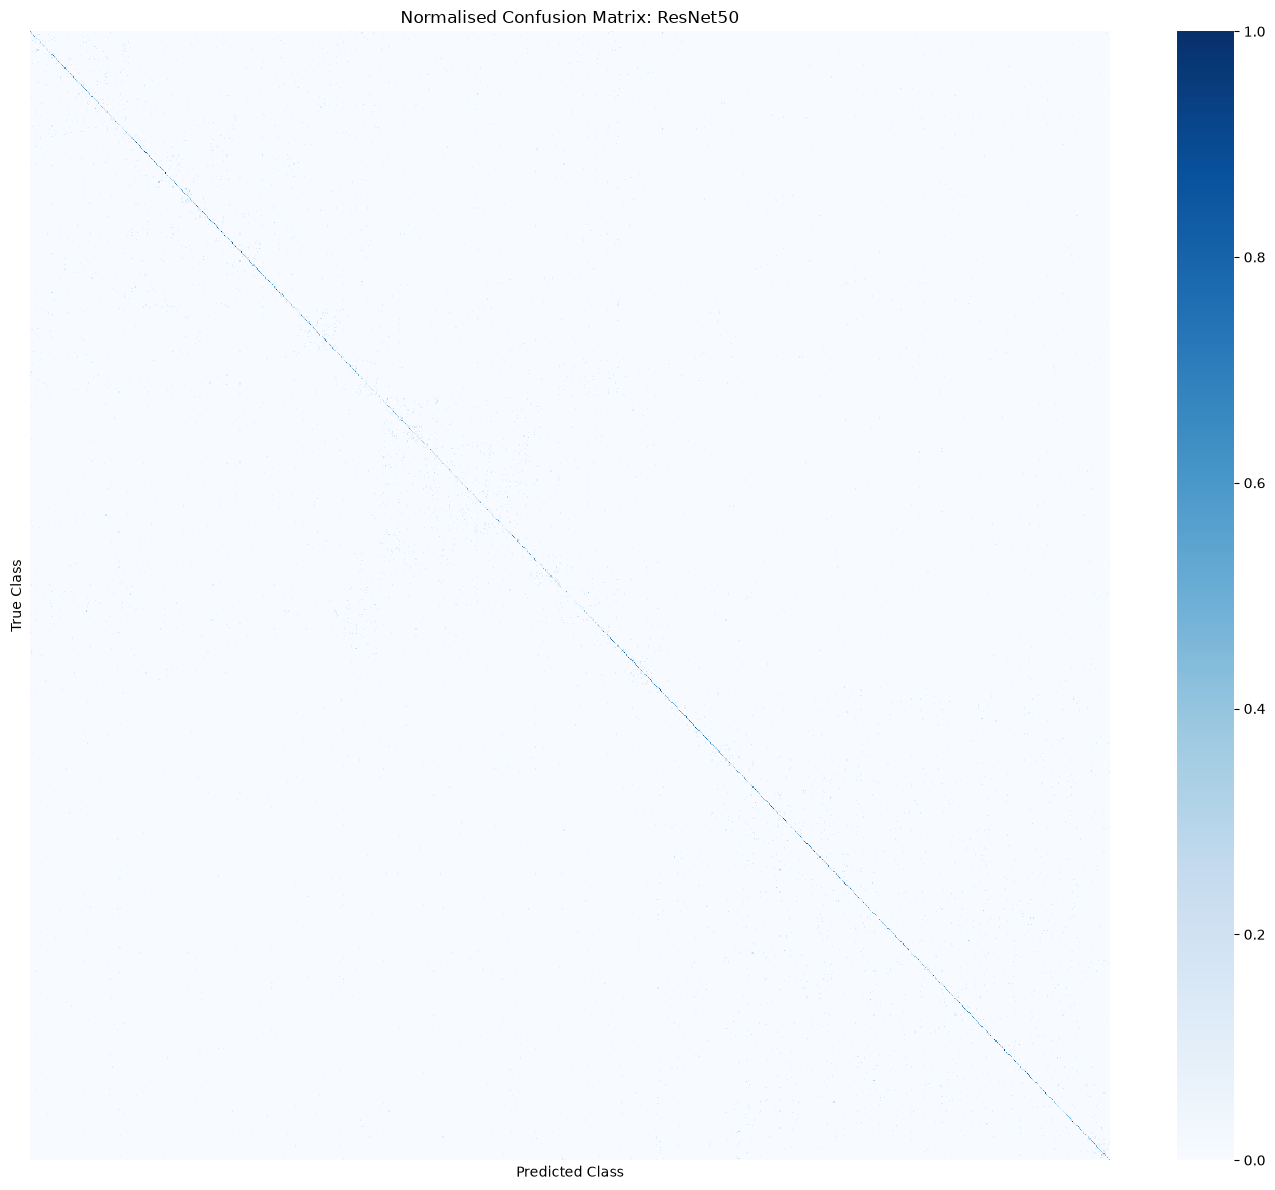

In [ ]:
DATA_ROOT = Path(r"D:/dataset/sampled_1000")

TEST_DIR = DATA_ROOT / "val"
MODEL_PATH = "inat_resnet18_1000_npclasses_imagenet.pth"

model = models.resnet18(weights=None)

testing(TEST_DIR,MODEL_PATH,model)
#1m19.1s

Number of classes: 1000
Classes: ['00001_Animalia_Annelida_Polychaeta_Sabellida_Sabellidae_Sabella_spallanzanii', '00003_Animalia_Annelida_Polychaeta_Sabellida_Serpulidae_Spirobranchus_cariniferus', '00004_Animalia_Arthropoda_Arachnida_Araneae_Agelenidae_Eratigena_duellica', '00018_Animalia_Arthropoda_Arachnida_Araneae_Araneidae_Argiope_bruennichi', '00024_Animalia_Arthropoda_Arachnida_Araneae_Araneidae_Cyclosa_turbinata', '00030_Animalia_Arthropoda_Arachnida_Araneae_Araneidae_Larinioides_cornutus', '00038_Animalia_Arthropoda_Arachnida_Araneae_Araneidae_Neoscona_crucifera', '00052_Animalia_Arthropoda_Arachnida_Araneae_Corinnidae_Nyssus_coloripes', '00055_Animalia_Arthropoda_Arachnida_Araneae_Filistatidae_Kukulcania_hibernalis', '00061_Animalia_Arthropoda_Arachnida_Araneae_Oxyopidae_Oxyopes_salticus', '00063_Animalia_Arthropoda_Arachnida_Araneae_Oxyopidae_Peucetia_viridans', '00105_Animalia_Arthropoda_Arachnida_Araneae_Sparassidae_Olios_giganteus', '00116_Animalia_Arthropoda_Arachnida_A

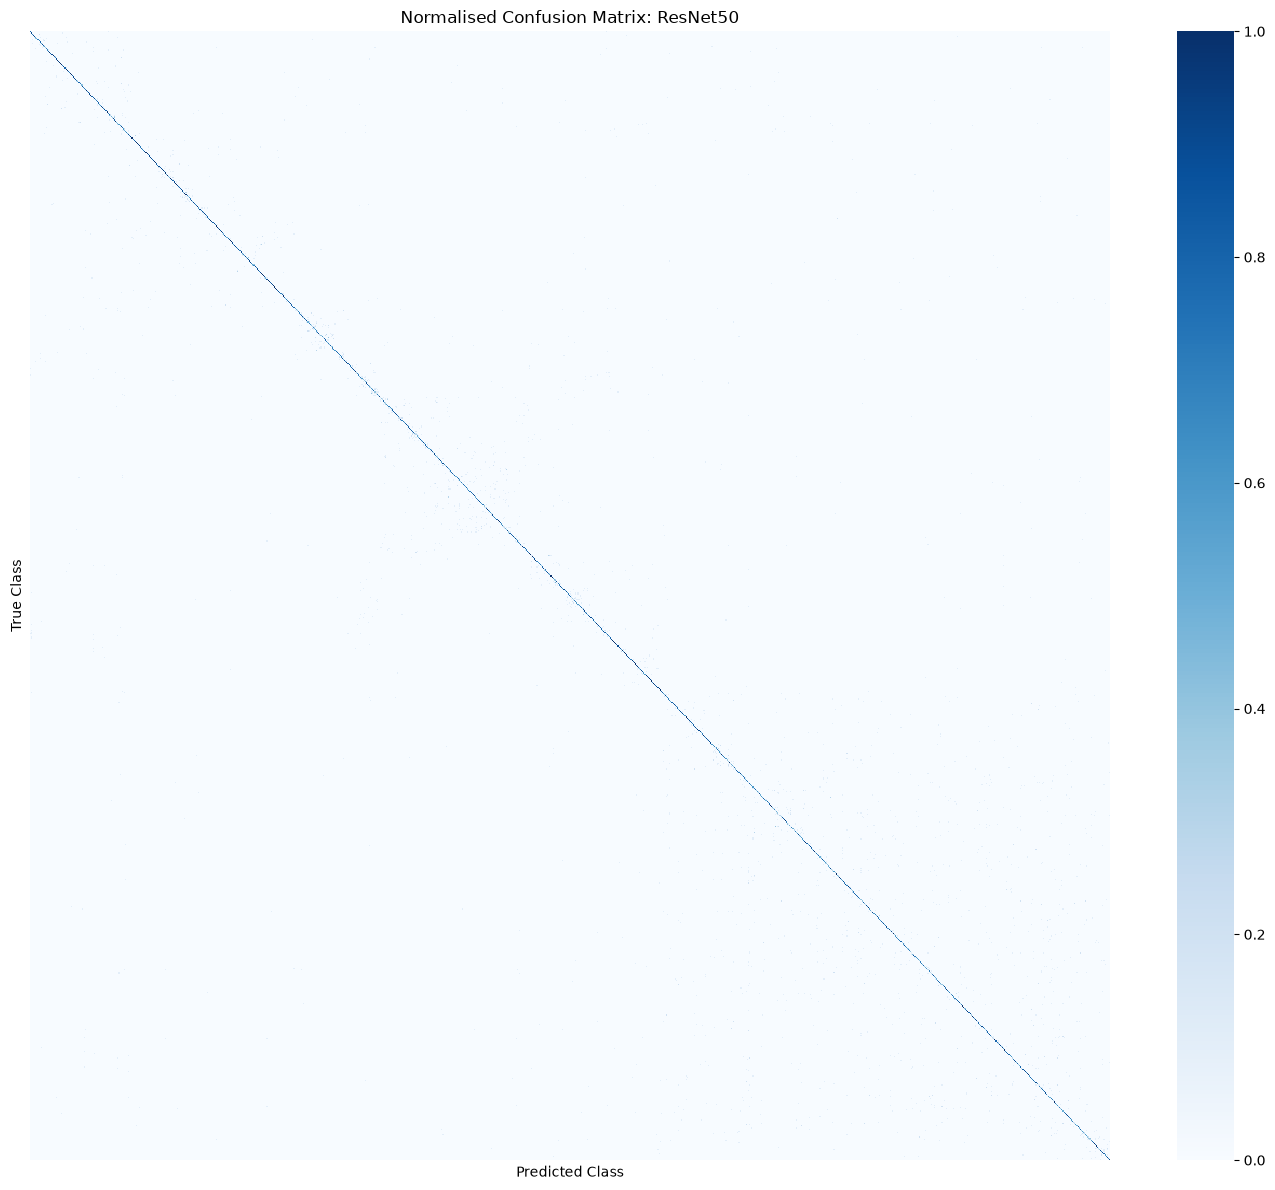

In [18]:
DATA_ROOT = Path(r"D:/dataset/sampled_1000")

TEST_DIR = DATA_ROOT / "val"
MODEL_PATH = "inat_resnet50_1000_ptclasses_imagenet.pth"

model = models.resnet50(weights=None)

testing(TEST_DIR,MODEL_PATH,model)
#1m29.5s

Number of classes: 1000
Classes: ['00001_Animalia_Annelida_Polychaeta_Sabellida_Sabellidae_Sabella_spallanzanii', '00003_Animalia_Annelida_Polychaeta_Sabellida_Serpulidae_Spirobranchus_cariniferus', '00004_Animalia_Arthropoda_Arachnida_Araneae_Agelenidae_Eratigena_duellica', '00018_Animalia_Arthropoda_Arachnida_Araneae_Araneidae_Argiope_bruennichi', '00024_Animalia_Arthropoda_Arachnida_Araneae_Araneidae_Cyclosa_turbinata', '00030_Animalia_Arthropoda_Arachnida_Araneae_Araneidae_Larinioides_cornutus', '00038_Animalia_Arthropoda_Arachnida_Araneae_Araneidae_Neoscona_crucifera', '00052_Animalia_Arthropoda_Arachnida_Araneae_Corinnidae_Nyssus_coloripes', '00055_Animalia_Arthropoda_Arachnida_Araneae_Filistatidae_Kukulcania_hibernalis', '00061_Animalia_Arthropoda_Arachnida_Araneae_Oxyopidae_Oxyopes_salticus', '00063_Animalia_Arthropoda_Arachnida_Araneae_Oxyopidae_Peucetia_viridans', '00105_Animalia_Arthropoda_Arachnida_Araneae_Sparassidae_Olios_giganteus', '00116_Animalia_Arthropoda_Arachnida_A

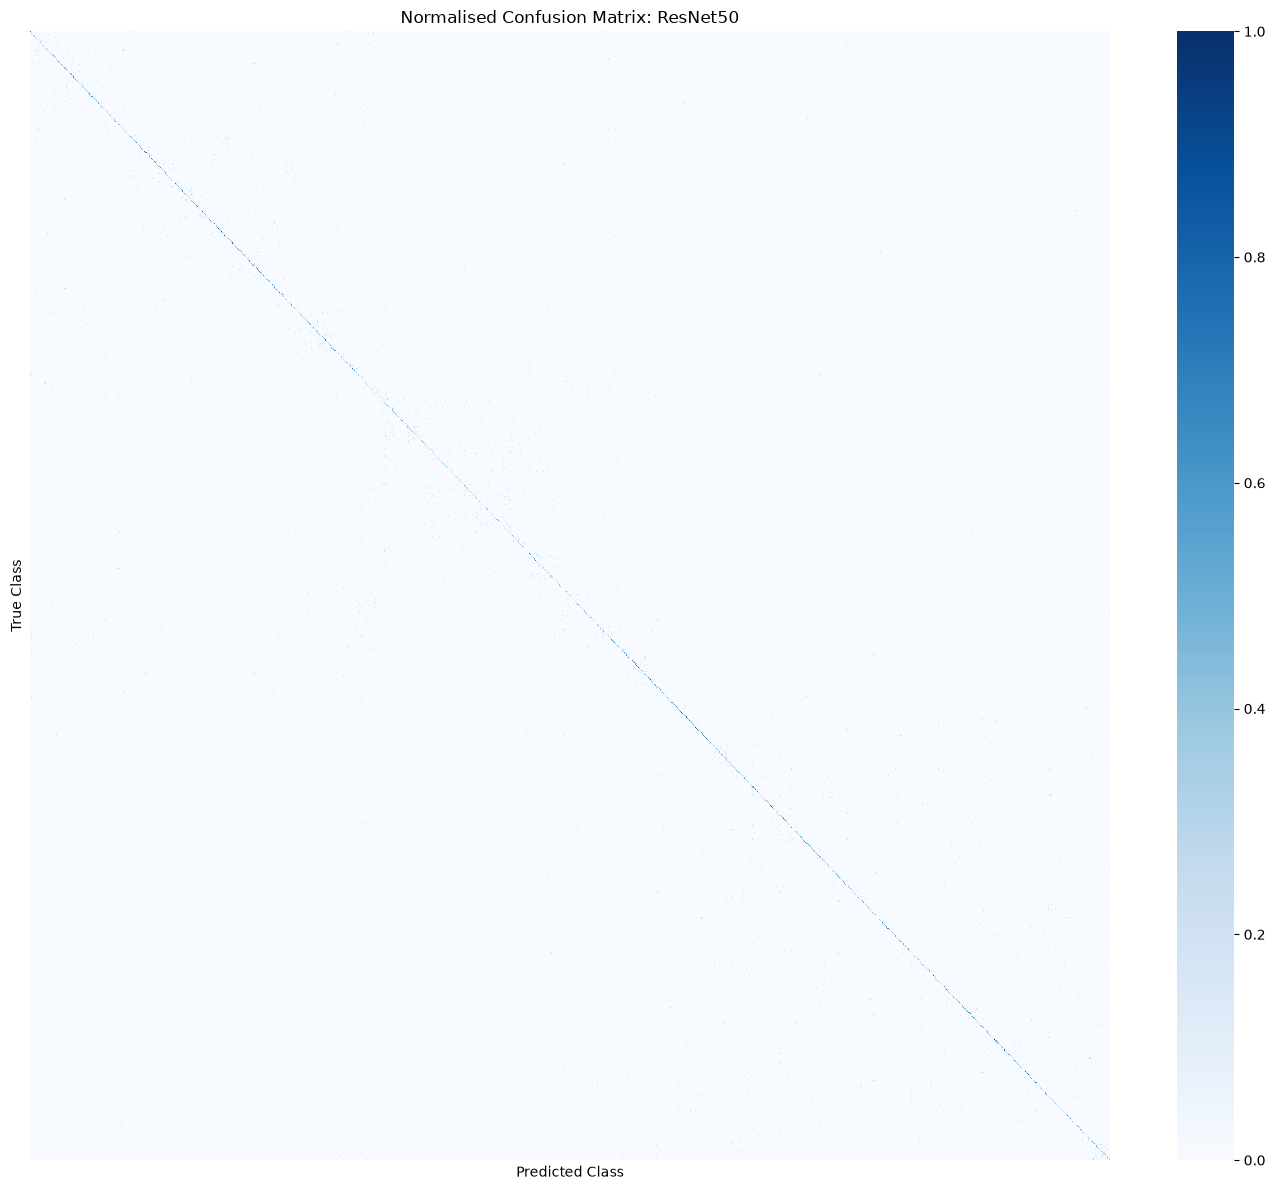

In [ ]:
DATA_ROOT = Path(r"D:/dataset/sampled_1000")

TEST_DIR = DATA_ROOT / "val"
MODEL_PATH = "inat_resnet50_1000_npclasses_imagenet.pth"

model = models.resnet50(weights=None)

testing(TEST_DIR,MODEL_PATH,model)
#1m45.4s